In [17]:
#IMPORTS

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid")

In [18]:
#Load Data Function
def load_data(path):
    return pd.read_csv(path)

In [19]:
#Missing Values Summary
def missing_summary(df):
    return (df.isnull().mean() * 100).sort_values(ascending=False)

In [20]:
#Cleaning + Imputation
def clean_and_impute(df):
    
    
    
    df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"], errors='coerce')
    
    df["policy_year"] = df["Policy Start Date"].dt.year
    df["policy_month"] = df["Policy Start Date"].dt.month
    
    df.drop(columns=["Policy Start Date", "Customer Feedback", "id"], inplace=True, errors='ignore')
   
    num_cols = df.select_dtypes(include="number").columns
    cat_cols = df.select_dtypes(exclude="number").columns
    
   
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    return df

## Data Cleaning
- Removed irrelevant columns such as `id` and `Customer Feedback`
- Converted `Policy Start Date` into datetime format
- Extracted new features: `policy_year` and `policy_month`
- Dropped original date column after feature extraction
## Missing Value Handling
- Numerical features were imputed using **median values**
- Categorical features were imputed using **most frequent (mode) values**
- This approach helps handle skewed data and maintains consistency

In [21]:
#Save Function
def save_data(df, path):
    df.to_csv(path, index=False)

## cleaned data is saved in precessed folder

## EDA

In [22]:
#Plot Functions
def plot_hist(df, col, title=None):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(title if title else col)
    plt.show()


def plot_box(df, x=None, y=None, col=None):
    plt.figure(figsize=(8,5))
    if col:
        sns.boxplot(x=df[col])
    else:
        sns.boxplot(x=x, y=y, data=df)
    plt.show()


def plot_count(df, col):
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

In [23]:
#Correlation
def plot_heatmap(df):
    plt.figure(figsize=(12,8))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm",annot=True,fmt=".2f")
    plt.show()

In [24]:
#Outlier Capping
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    
    return df

Previous Claims         30.335750
Occupation              29.839583
Credit Score            11.490167
Number of Dependents     9.139333
Customer Feedback        6.485333
Health Score             6.173000
Annual Income            3.745750
Age                      1.558750
Marital Status           1.544083
Vehicle Age              0.000500
Insurance Duration       0.000083
Gender                   0.000000
id                       0.000000
Location                 0.000000
Policy Type              0.000000
Education Level          0.000000
Policy Start Date        0.000000
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
Premium Amount           0.000000
dtype: float64


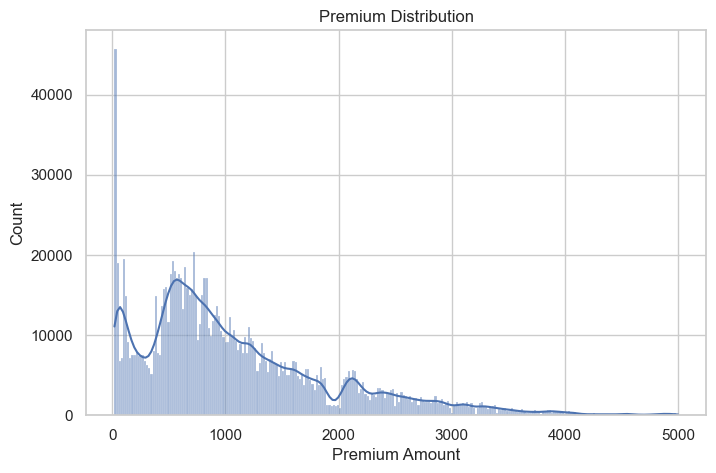

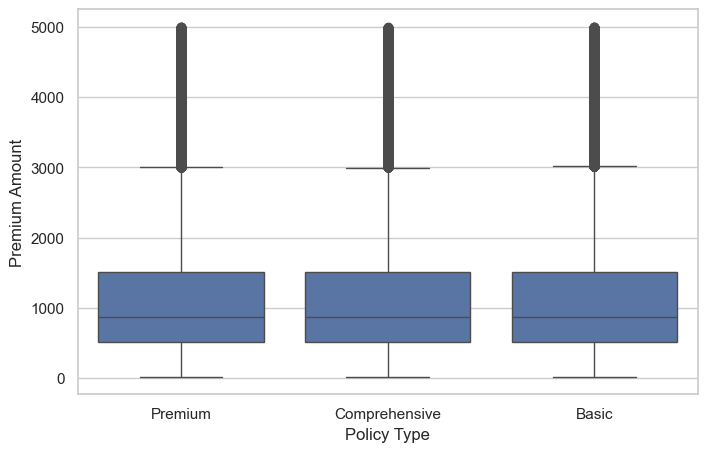

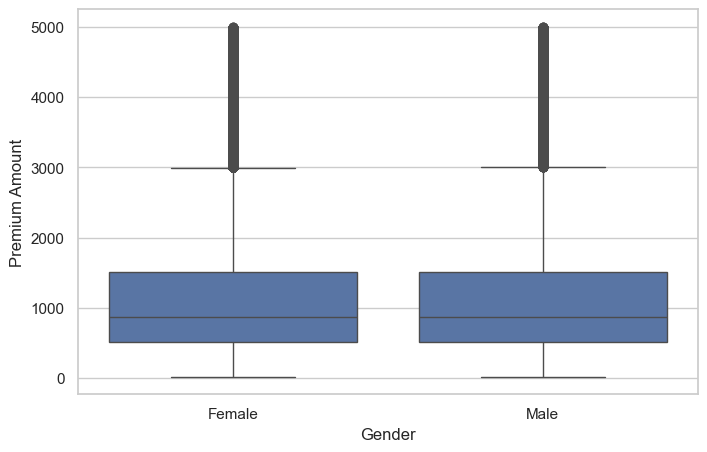

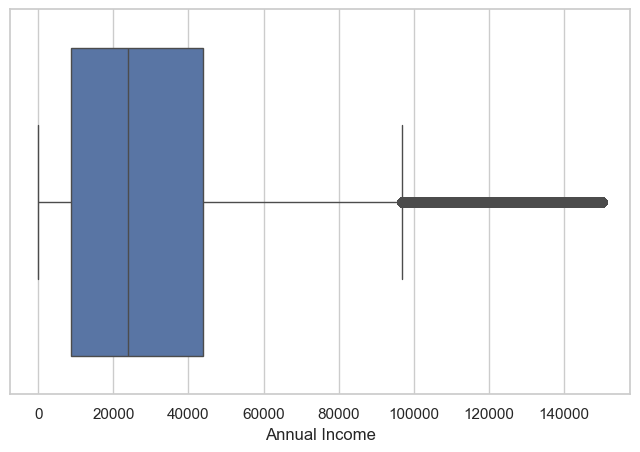

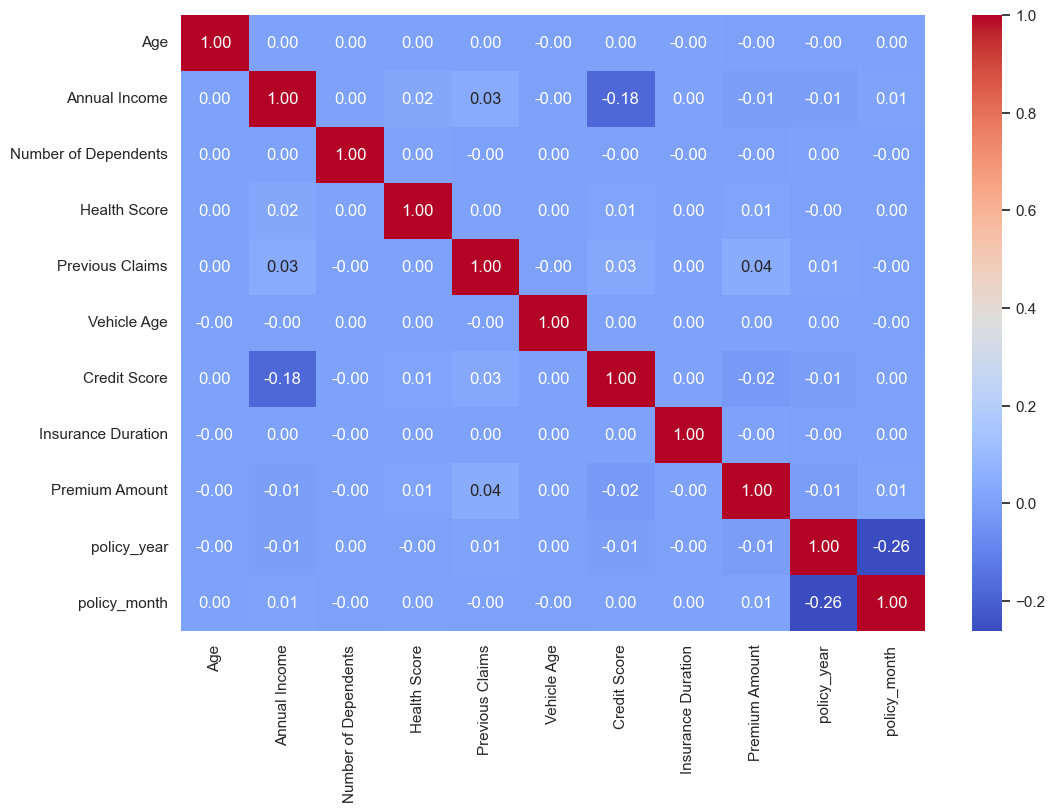

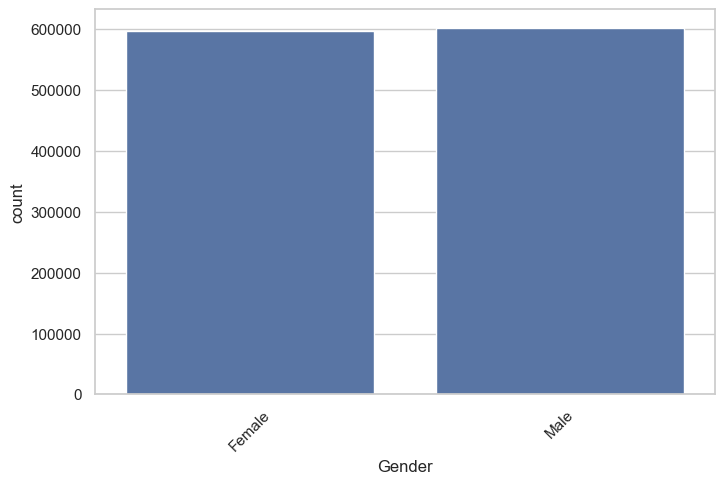

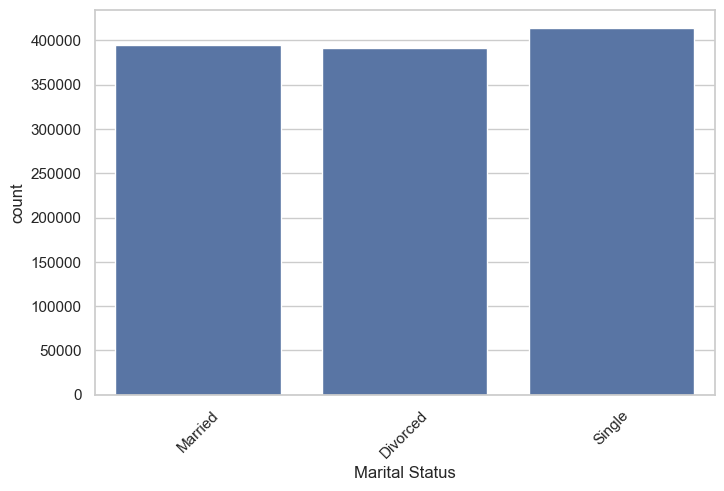

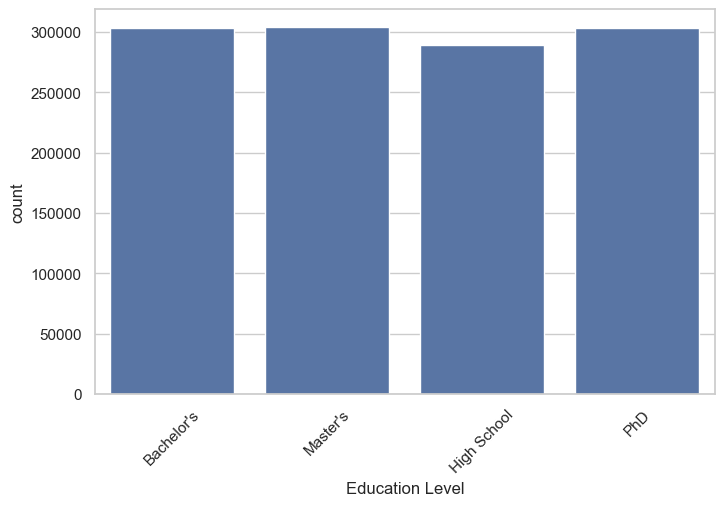

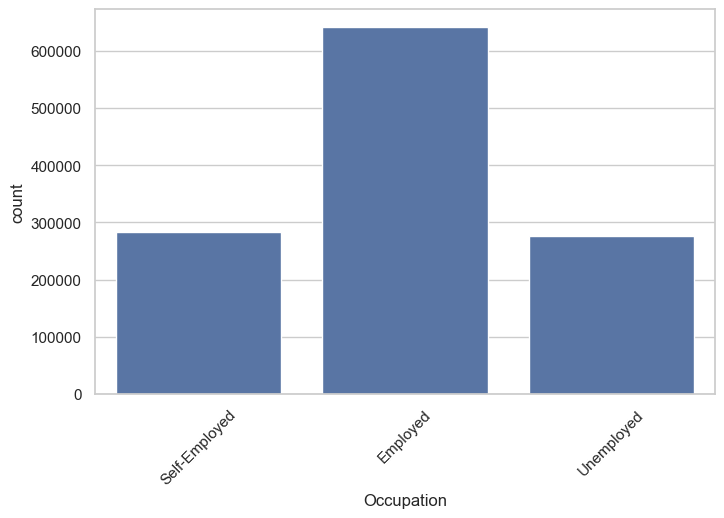

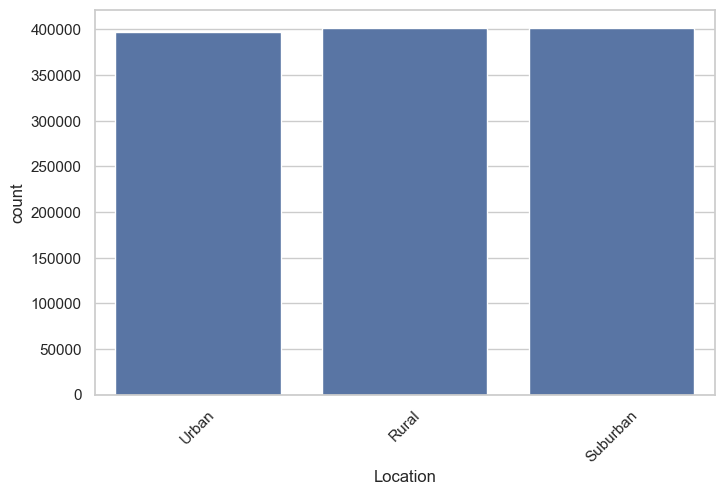

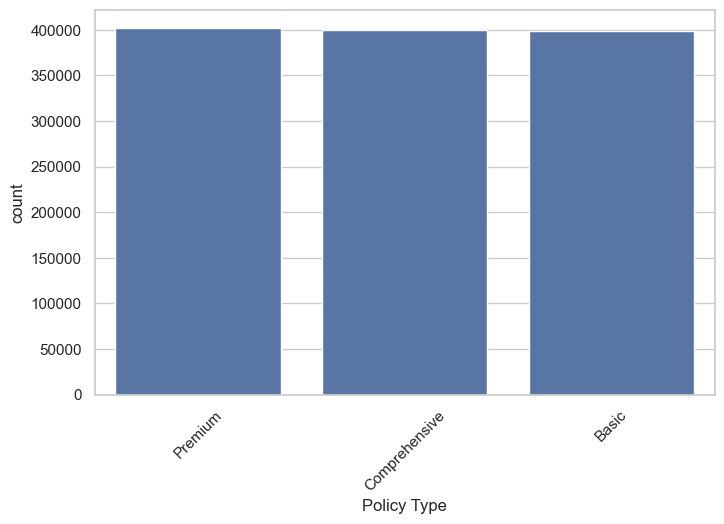

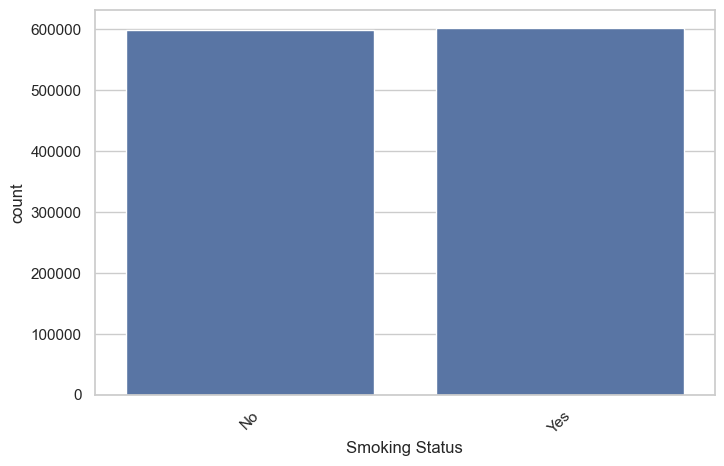

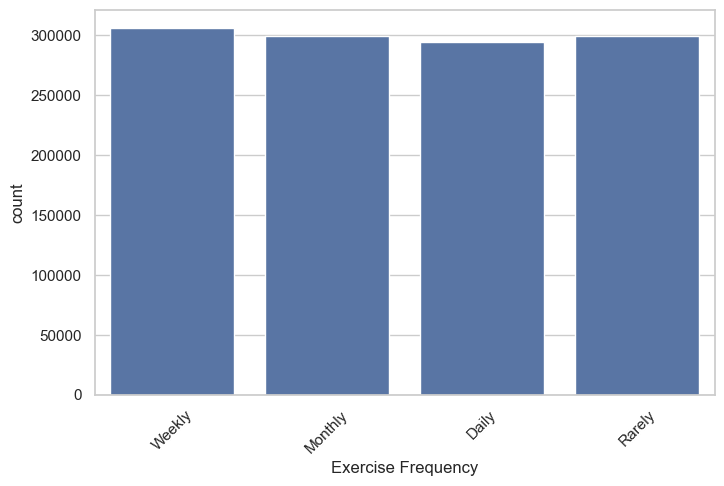

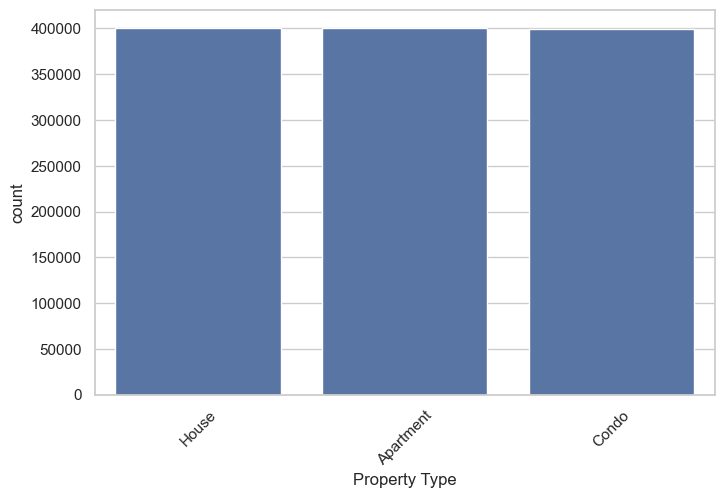

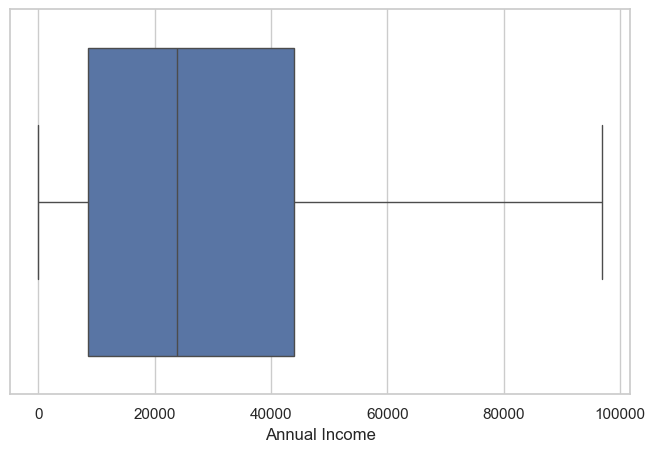

In [26]:
#MAIN EXECUTION
# Load
df = load_data("../data/raw/train.csv")

# Missing summary
print(missing_summary(df))

# Clean
df = clean_and_impute(df)

# Save cleaned
df.to_csv(
    "../data/processed/train_cleaned.csv",
    index=False
)

# EDA
plot_hist(df, "Premium Amount", "Premium Distribution")

plot_box(df, x="Policy Type", y="Premium Amount")
plot_box(df, x="Gender", y="Premium Amount")
plot_box(df, col="Annual Income")

#heatmap
plot_heatmap(df)

# Categorical plots
for col in df.select_dtypes(exclude="number").columns:
    plot_count(df, col)



# Outlier capping
exclude_cols = [
    "Premium Amount",
    "policy_year",
    "policy_month"
]

num_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col not in exclude_cols
]
df = cap_outliers(df, num_cols)

# After capping
plot_box(df, col="Annual Income")

## Target Variable Analysis
- Premium Amount shows a **right-skewed distribution**
- Indicates presence of high-value outliers
- Log transformation will be applied to normalize distribution

## Feature Relationships
- Higher annual income tends to correspond with higher premium amounts
- Policy Type significantly impacts premium (Premium > Comprehensive > Basic)
- Previous claims increase premium cost
- Health score influences premium (lower health → higher premium)

## Correlation Analysis
- Premium Amount positively correlates with:
  - Annual Income
  - Previous Claims
- Negative or weak correlation with some features
- No strong multicollinearity observed

## Categorical Features
- Distribution varies across categories
- Some imbalance observed in features like Occupation and Property Type

## Final Summary
- Dataset is large and suitable for machine learning
- Missing values handled using imputation
- Target variable is skewed → log transformation required
- Several features show meaningful relationships with premium
- Data is ready for preprocessing and model building

### Key Insights

1. **Income vs Premium**
   - Customers with higher annual income tend to have higher premium amounts.
   - This indicates that premium pricing is influenced by the customer’s financial capacity and coverage choices.

2. **Health Score vs Premium**
   - Customers with lower health scores are associated with higher premium amounts.
   - This suggests that individuals with poorer health pose higher risk, leading to increased insurance costs.

3. **Previous Claims vs Premium**
   - Customers with a higher number of previous claims tend to pay higher premiums.
   - This reflects risk-based pricing, where past claim history significantly impacts future premium calculations.

## Outlier Treatment
- The target variable showed skewness and was handled using log transformation
- Instead of removing outliers, numerical features were capped using the IQR method
- This approach preserves data while reducing extreme value impact